# MF3 — Reaction Cross Sections

Parsing, data access, plotting via `PlotBuilder`, and the MF2 resonance gap.

In [1]:
import numpy as np
from kika.endf import read_endf, read_mf3_mt
from kika.plotting import PlotBuilder

ENDF_FILE = '/home/MONLEON-JUAN/kika/kika/endf/files/n-026_Fe_056.endf'

## 1. Parse the file and inspect available MF3 sections

In [2]:
endf = read_endf(ENDF_FILE, mf_numbers=3)
mf3 = endf.mf[3]
print(f"{len(mf3.sections)} MT sections: {sorted(mf3.sections.keys())}")

74 MT sections: [1, 2, 3, 4, 5, 16, 22, 28, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 91, 102, 103, 104, 105, 106, 107, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 649, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 849]


## 2. Access key fields from a section

In [3]:
mt1 = mf3[1]   # total cross section
mt2 = mf3[2]   # elastic scattering
mt102 = mf3[102]  # radiative capture

for label, sec in [('MT1 (total)', mt1), ('MT2 (elastic)', mt2), ('MT102 (n,gamma)', mt102)]:
    print(f"{label}:")
    print(f"  ZA={sec.zaid}  AWR={sec.atomic_weight_ratio:.4f}")
    print(f"  QM={sec.q_mass_difference:.1f} eV   QI={sec.q_reaction:.1f} eV   LR={sec.breakup_flag}")
    print(f"  {sec.num_energy_points} points, {sec.num_interpolation_regions} interp region(s)")
    print(f"  E range: [{sec.energies[0]:.4e}, {sec.energies[-1]:.4e}] eV")
    print()

MT1 (total):
  ZA=26056  AWR=55.4544
  QM=0.0 eV   QI=0.0 eV   LR=0
  11886 points, 1 interp region(s)
  E range: [1.0000e-05, 2.0000e+08] eV

MT2 (elastic):
  ZA=26056  AWR=55.4544
  QM=0.0 eV   QI=0.0 eV   LR=0
  11145 points, 1 interp region(s)
  E range: [1.0000e-05, 2.0000e+08] eV

MT102 (n,gamma):
  ZA=26056  AWR=55.4544
  QM=7646700.0 eV   QI=7646700.0 eV   LR=0
  52 points, 1 interp region(s)
  E range: [1.0000e-05, 2.0000e+08] eV



## 3. Point-wise interpolation via `get_cross_section()`

In [4]:
e_query = np.array([1e-2, 1.0, 1e3, 1e5, 1e6, 5e6, 1.4e7, 2e7])
xs_total = mt1.get_cross_section(e_query)
xs_elastic = mt2.get_cross_section(e_query)

print(f"{'E (eV)':>12s}  {'total (b)':>10s}  {'elastic (b)':>11s}")
for e, st, se in zip(e_query, xs_total, xs_elastic):
    print(f"{e:12.3e}  {st:10.4f}  {se:11.4f}")

      E (eV)   total (b)  elastic (b)
   1.000e-02      0.0000       0.0000
   1.000e+00      0.0000       0.0000
   1.000e+03      0.0000       0.0000
   1.000e+05      0.0000       0.0000
   1.000e+06      2.2829       1.3790
   5.000e+06      3.4889       2.1414
   1.400e+07      2.5891       1.1641
   2.000e+07      2.2300       0.9522


## 4. Plot total, elastic and capture via PlotBuilder

/home/MONLEON-JUAN/kika/kika/plotting/plot_builder.py:1807: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  self.ax.set_ylim(y_min, y_max)


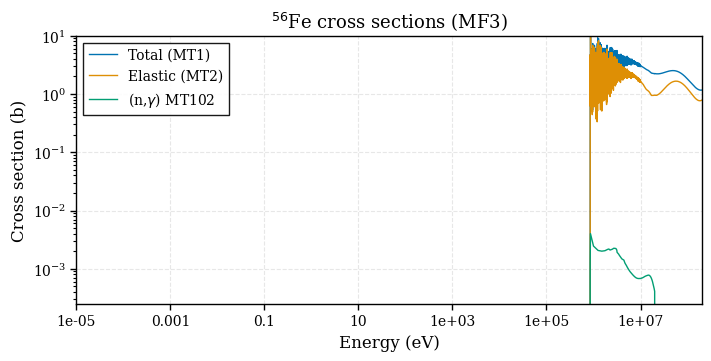

In [5]:
builder = PlotBuilder(figsize=(10, 5))

builder.add_data(mt1.to_plot_data(label='Total (MT1)'))
builder.add_data(mt2.to_plot_data(label='Elastic (MT2)'))
builder.add_data(mt102.to_plot_data(label='(n,$\\gamma$) MT102'))

builder.set_labels(title='$^{56}$Fe cross sections (MF3)',
                   x_label='Energy (eV)', y_label='Cross section (b)')
builder.set_scales(log_x=True, log_y=True)
builder.set_legend(loc='best')
fig = builder.build()

## 5. MF3 / MF2 resonance gap

ENDF splits cross section data between MF2 (resolved/unresolved resonance parameters)
and MF3 (smooth background). In the resonance region the MF3 curve may be identically
zero or carry only a smooth background — the actual cross section requires
reconstructing resonances from MF2 and adding them to the MF3 background.

The zoom below shows this gap in the elastic channel.

/home/MONLEON-JUAN/kika/kika/plotting/plot_builder.py:1807: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  self.ax.set_ylim(y_min, y_max)


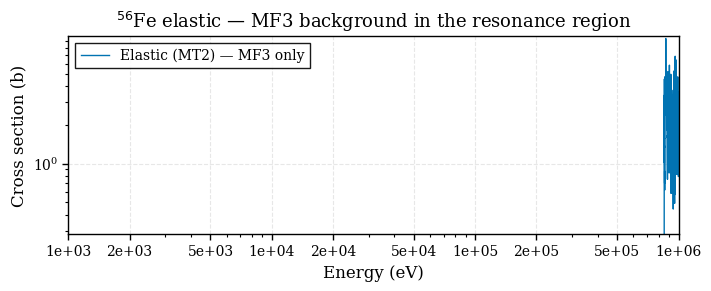

In [6]:
builder = PlotBuilder(figsize=(10, 4))
builder.add_data(mt2.to_plot_data(label='Elastic (MT2) — MF3 only'))
builder.set_labels(title='$^{56}$Fe elastic — MF3 background in the resonance region',
                   x_label='Energy (eV)', y_label='Cross section (b)')
builder.set_scales(log_x=True, log_y=True)
builder.set_limits(x_lim=(1e3, 1e6))
builder.set_legend(loc='best')
fig = builder.build()

## 6. Threshold reactions and Q-values

In [7]:
threshold_mts = [(mt, sec) for mt, sec in sorted(mf3.sections.items())
                 if sec.q_reaction < 0]

print(f"{'MT':>5s}  {'QI (MeV)':>10s}  {'Ethresh (MeV)':>13s}  {'NP':>6s}")
for mt_num, sec in threshold_mts[:10]:
    print(f"{mt_num:5d}  {sec.q_reaction/1e6:10.4f}  {sec.energies[0]/1e6:13.4f}  {sec.num_energy_points:6d}")

   MT    QI (MeV)  Ethresh (MeV)      NP
    4     -0.8470         0.8623    6915
   16    -11.1970        11.3989      16
   22     -7.6131         7.7504      29
   28    -10.1840        10.3676      22
   51     -0.8470         0.8623    5227
   52     -2.0850         2.1226    4286
   53     -2.6580         2.7059    3116
   54     -2.9420         2.9951    2633
   55     -2.9600         3.0134    2605
   56     -3.1200         3.1763    2375


## 7. Overlay several inelastic levels

/home/MONLEON-JUAN/kika/kika/plotting/plot_builder.py:1807: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  self.ax.set_ylim(y_min, y_max)


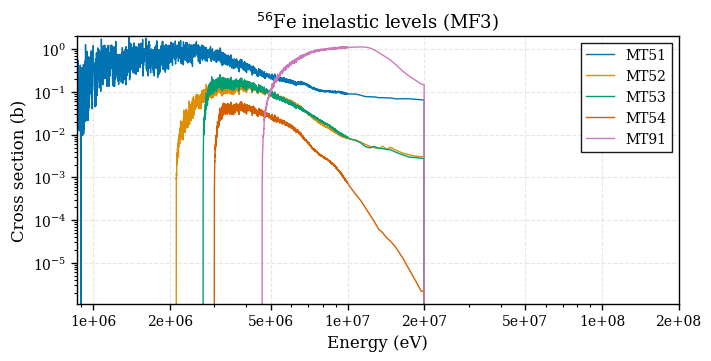

In [8]:
builder = PlotBuilder(figsize=(10, 5))

for mt_num in [51, 52, 53, 54, 91]:
    sec = mf3.sections.get(mt_num)
    if sec is not None:
        builder.add_data(sec.to_plot_data(label=f'MT{mt_num}'))

builder.set_labels(title='$^{56}$Fe inelastic levels (MF3)',
                   x_label='Energy (eV)', y_label='Cross section (b)')
builder.set_scales(log_x=True, log_y=True)
builder.set_legend(loc='best')
fig = builder.build()

## 8. Convenience reader `read_mf3_mt()`

In [9]:
mt18 = read_mf3_mt(ENDF_FILE, 18)  # fission — None for Fe-56
print(f"MT18 (fission) for Fe-56: {mt18}")

mt107 = read_mf3_mt(ENDF_FILE, 107)  # (n,alpha)
print(f"MT107 (n,alpha): {mt107.num_energy_points} points, "
      f"QI={mt107.q_reaction/1e6:.3f} MeV")

MT18 (fission) for Fe-56: None
MT107 (n,alpha): 38 points, QI=0.326 MeV


## 9. Round-trip: parse → str() → re-parse

In [10]:
from kika.endf.parsers.parse_mf3 import parse_mf3_mt

sec = mf3[102]
text = str(sec)
# strip SEND line (MT=0) before re-parsing
data_lines = [l for l in text.split('\n') if not (len(l) >= 75 and l[72:75].strip() == '0')]
reparsed = parse_mf3_mt(data_lines, 102)

assert reparsed._energies == sec._energies
assert reparsed._cross_sections == sec._cross_sections
assert reparsed._interpolation == sec._interpolation
assert reparsed._qm == sec._qm and reparsed._qi == sec._qi
print(f"MT102 round-trip OK  ({sec.num_energy_points} points)")

MT102 round-trip OK  (52 points)


## 10. Reconstructed cross sections via `to_plot_data(reconstructed=True)`

The raw MF3 data contains only the smooth background — identically zero in the
resolved resonance region.  Setting `reconstructed=True` auto-reconstructs from
MF2 resonance parameters + MF3 background (cached after the first call).

In [ ]:
# Load MF2 + MF3 for reconstruction
endf_full = read_endf(ENDF_FILE, mf_numbers=[2, 3])

# One-liner: full reconstructed elastic cross section
data_recon, _ = endf_full.to_plot_data(mf=3, mt=2, reconstructed=True, uncertainty=False)

# Compare with raw MF3 background
data_raw = endf_full.to_plot_data(mf=3, mt=2, uncertainty=False)

builder = PlotBuilder(figsize=(10, 5))
builder.add_data(data_recon)
builder.add_data(data_raw)
builder.set_labels(title='$^{56}$Fe elastic — raw MF3 background vs reconstructed',
                   x_label='Energy (eV)', y_label='Cross section (b)')
builder.set_scales(log_x=True, log_y=True)
builder.set_legend(loc='best')
fig = builder.build()

## 11. Cross section uncertainties from MF33

`uncertainty=True` (default for MF3) extracts covariance data from MF33 and
returns a `(PlotData, UncertaintyBand)` tuple — the same pattern as MF4 + MF34.

In [ ]:
# Load MF3 + MF33 for uncertainty bands
endf_unc = read_endf(ENDF_FILE, mf_numbers=[3, 33])

# Plot capture cross section with MF33 uncertainty band
data_xs, unc_band = endf_unc.to_plot_data(mf=3, mt=102)

builder = PlotBuilder(figsize=(10, 5))
builder.add_data(data_xs, uncertainty=unc_band)
builder.set_labels(title='$^{56}$Fe (n,$\\gamma$) MT102 — MF3 with MF33 uncertainties',
                   x_label='Energy (eV)', y_label='Cross section (b)')
builder.set_scales(log_x=True, log_y=True)
builder.set_legend(loc='best')
fig = builder.build()

## 12. Combined: reconstructed + uncertainty

Load MF2, MF3, and MF33 together for the full picture: reconstructed pointwise
cross sections with MF33 uncertainty bands.

In [ ]:
# Load all three: MF2 (resonances) + MF3 (background) + MF33 (covariance)
endf_all = read_endf(ENDF_FILE, mf_numbers=[2, 3, 33])

# Full reconstructed cross section with uncertainty bands
data_full, unc_full = endf_all.to_plot_data(mf=3, mt=102, reconstructed=True)

builder = PlotBuilder(figsize=(10, 5))
builder.add_data(data_full, uncertainty=unc_full)
builder.set_labels(title='$^{56}$Fe (n,$\\gamma$) — reconstructed with MF33 uncertainties',
                   x_label='Energy (eV)', y_label='Cross section (b)')
builder.set_scales(log_x=True, log_y=True)
builder.set_legend(loc='best')
fig = builder.build()